# 4. Default Prediction: Tree-Based Models 

### Outline of this notebook:
* **Section 1:** Objective  
* **Section 2:** Load Cleaned Dataset  
* **Section 3:** Feature Preprocessing  
  * 3.1 Define feature types  
  * 3.2 Train-validation-test split (time-based)  
  * 3.3 Preprocessing for tree models  
* **Section 4:** Random Forest  
* **Section 5:** Gradient Boosting Model - XGBoost  
* **Section 6:** LightGBM  
* **Section 7:** XGBoost Interpretation (SHAP Values)

---
## Section 1: Objective

In this notebook, we build and evaluate tree-based models for predicting loan default, including Random Forest and gradient boosting methods (XGBoost). 

Compared to logistic regression, these models can capture **nonlinear relationships and interactions** between variables without requiring manual feature engineering. As a result, they often achieve stronger predictive performance in credit risk settings.

The algorithm also provides measures of predictor importance, though these are **less immediately interpretable** than logistic regression coefficients, which have a clear relationship with changes in predicted risk.

---
## Section 2: Load Cleaned Dataset 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)

import time
from datetime import timedelta
import shap

In [5]:
df_cleaned = pd.read_parquet("../data/processed/LendingClub_features.parquet")

In [6]:
df_cleaned.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,payment_to_income,fico_util_interaction,inq_per_credit_year,dti_x_int_rate,loan_to_installment,delinq_rate,fico_band,dti_band,unemployment_rate,fed_funds_rate
0,5000.0,36.0,0.1065,162.87,B,B2,10.0,RENT,24000.0,Verified,...,0.069444,615.195,0.024183,2.944725,30.699331,0.0,good,medium,8.5,0.07
1,2500.0,60.0,0.1527,59.83,C,C4,0.5,RENT,30000.0,Source Verified,...,0.016667,69.560,0.184530,0.152700,41.785057,0.0,good,very_low,8.5,0.07
2,2400.0,36.0,0.1596,84.33,C,C5,10.0,RENT,12252.0,Not Verified,...,0.065295,723.975,0.081610,1.391712,28.459623,0.0,good,very_low,8.5,0.07
3,10000.0,36.0,0.1349,339.31,C,C1,10.0,RENT,49200.0,Source Verified,...,0.067751,144.900,0.033047,2.698000,29.471575,0.0,good,low,8.5,0.07
4,3000.0,60.0,0.1269,67.79,B,B5,1.0,RENT,80000.0,Source Verified,...,0.007500,374.605,0.000000,2.276586,44.254314,0.0,good,low,8.5,0.07


#### Limit to pre-COVID loans

To ensure a stable and consistent economic environment, I exclude observations from the COVID-19 period and restrict the analysis to loans issued up to 2019. This avoids potential distortions driven by the unprecedented shocks during the pandemic.

In [8]:
df_cleaned['issue_d'].agg(['min', 'max'])

min   2007-06-01
max   2020-09-01
Name: issue_d, dtype: datetime64[ns]

In [9]:
print(f"Number of observations before restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations before restricting to 2019-12-01: 1,860,765


In [10]:
df_cleaned = df_cleaned[df_cleaned['issue_d'] <= '2019-12-01']

In [11]:
print(f"Number of observations after restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations after restricting to 2019-12-01: 1,856,478


---
## Section 3: Feature Preprocessing

In this section, I prepare the features for tree-based models using a streamlined preprocessing pipeline.

The main steps are as follows:

- **3.1: Define feature types**: Separate variables into numerical and categorical features.

- **3.2: Train-validation-test split**

- **3.3: Build preprocessing pipeline**:
  - **Categorical variables**: Impute missing values using the most frequent value and apply one-hot encoding, converting each category into binary (0/1) indicator variables.
  - **Numerical variables**: Impute missing values using the median.
  - Unlike logistic regression, tree-based models do not require feature scaling, as they are not sensitive to the scale of input variables.
  - These steps are implemented using `ColumnTransformer` and `Pipeline` from `sklearn`, and are applied during model training rather than directly modifying `df_cleaned`. This ensures consistency, reproducibility, and prevents data leakage.

### 🔷 3.1: Define feature types

In [14]:
# 1. Target variable
target = 'default'

# 2. Variables to drop (before modeling)
drop_cols = ['zip_code', 'grade', 'addr_state']  
    # grade: 
    #  - redundant to 'sub_grade' (see 2_exploratory_data_analysis)
    # addr_state, zip_code:
    #  - will drop geographic variables 
    #    to avoid potential proxy effects for protected characteristics
    #    and mitigate fairness / regulatory concerns in credit risk modeling.

# 3. Time-related (handle separately)
date_cols = ['issue_d']

# 4. Categorical features
categorical_cols = [
    'sub_grade', 
    'home_ownership', 'verification_status',
    'purpose',
    'initial_list_status', 'application_type',
    'fico_band', 'dti_band'
]

# 5. Numeric features (all the others)
numeric_cols = [
    col for col in df_cleaned.columns
    if col not in categorical_cols + date_cols + drop_cols + [target]
]

# 6. Final check
print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))
print("Date:", date_cols)

Numeric: 62
Categorical: 8
Date: ['issue_d']


In [15]:
# print(numeric_cols) ## Checking numeric features 

### 🔷 3.2: Train-validation-test split (time-based)

In [17]:
# Start from original data
X = df_cleaned.copy()

# Drop unnecessary columns
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

# Target
y = df_cleaned[target]

# Combine
df_model = X.copy()
df_model[target] = y

# Sort by issue date
df_model = df_model.sort_values("issue_d")

# Split indices
n = len(df_model)
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# Split data (time-based)
X_train = df_model.iloc[:train_end].drop(columns=[target])
y_train = df_model.iloc[:train_end][target]

X_val = df_model.iloc[train_end:val_end].drop(columns=[target])
y_val = df_model.iloc[train_end:val_end][target]

X_test = df_model.iloc[val_end:].drop(columns=[target])
y_test = df_model.iloc[val_end:][target]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (1113886, 71)
Validation size: (371296, 71)
Test size: (371296, 71)


In [18]:
# Check date ranges
print(f"Train date range: {X_train['issue_d'].min().date()} → {X_train['issue_d'].max().date()}")
print(f"Validation date range: {X_val['issue_d'].min().date()} → {X_val['issue_d'].max().date()}")
print(f"Test date range: {X_test['issue_d'].min().date()} → {X_test['issue_d'].max().date()}")

Train date range: 2007-06-01 → 2016-07-01
Validation date range: 2016-07-01 → 2017-08-01
Test date range: 2017-08-01 → 2019-12-01


In [19]:
# [Important] Drop time variable (not used for prediction)
X_train = X_train.drop(columns=["issue_d"])
X_val = X_val.drop(columns=["issue_d"]) 
X_test  = X_test.drop(columns=["issue_d"])

In [20]:
## Combined train + val dataset for final model refit after hyperparameter tuning
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f"Train+Val size: {X_trainval.shape[0]:,} rows")

Train+Val size: 1,485,182 rows


### 🔷 3.3: Build Preprocessing Pipeline

To ensure consistent and reproducible feature transformations, I construct a preprocessing pipeline using `ColumnTransformer` and `Pipeline` from `sklearn`.

- **Categorical variables**:
  - Missing values are imputed using the most frequent value.
  - Variables are then one-hot encoded, converting each category into a binary (0/1) indicator variable.

- **Numerical variables**:
  - Missing values are imputed using the median.
  - Unlike logistic regression, feature scaling is not applied, as tree-based models are not sensitive to the scale of input variables.

These transformations are applied within the modeling pipeline during training, rather than directly modifying the dataset. This ensures that the same preprocessing steps are consistently applied across training, validation, and test sets, and helps prevent data leakage.

In [22]:
# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Numerical pipeline (no scaling for tree models)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Combined preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_cols),
    ("cat", cat_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready (tree-based).")

Preprocessing pipeline ready (tree-based).


---
## Section 4: Random Forest

In this section, we build a Random Forest model using the full feature set. 

We begin with Random Forest (rather than directly using boosting methods like XGBoost) because it provides a **strong, stable baseline** that is less sensitive to hyperparameters and easier to interpret. This helps establish a benchmark before moving to more complex models that may offer incremental gains at the cost of additional tuning. In addition, comparing Random Forest results with the logistic regression models from Notebook 3 allows us to assess **how much nonlinearities and interactions improve predictive performance**.

We perform **cross-validation** to tune key hyperparameters, particularly:
- `max_depth` (controls tree complexity)  
- `min_samples_leaf` (controls minimum observations per leaf)

Model performance is evaluated using standard metrics, including:
- **ROC-AUC** (discriminatory power)  
- **Precision and Recall** (classification performance at a chosen threshold)

Finally, we examine **feature importance** to understand which variables contribute most to predictions, noting that importance measures in tree-based models are less directly interpretable than coefficients in logistic regression.

In [24]:
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 4.1 Baseline model
# -----------------------------
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [25]:
# Fit on training data
start = time.time()

# Fit model
rf_pipeline.fit(X_train, y_train)

end = time.time()

elapsed = timedelta(seconds=end - start)

print(f"Random Forest = Training time: {elapsed}")

Random Forest = Training time: 0:03:50.312048


In [26]:
# Try a few configurations
param_grid_rf = [
    {"max_depth": None, "min_samples_leaf": 5},
    {"max_depth": 10, "min_samples_leaf": 5},
    {"max_depth": 15, "min_samples_leaf": 10},
]

results_rf = []

for params in param_grid_rf:
    
    model_rf = Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    model_rf.fit(X_train, y_train)
    
    y_val_proba_rf = model_rf.predict_proba(X_val)[:, 1]
    auc_rf = roc_auc_score(y_val, y_val_proba_rf)
    
    results_rf.append({
        "params": params,
        "val_auc": auc_rf,
        "model": model_rf
    })

# Select best model
best_result_rf = max(results_rf, key=lambda x: x["val_auc"])
best_model_rf = best_result_rf["model"]

print("Best params:", best_result_rf["params"])
print("Best validation AUC:", best_result_rf["val_auc"])

Best params: {'max_depth': None, 'min_samples_leaf': 5}
Best validation AUC: 0.7145602365153509


In [27]:
## Refit best RF on train + val combined
best_params_rf = best_result_rf["params"]

best_model_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=best_params_rf["max_depth"],
        min_samples_leaf=best_params_rf["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    ))
])

start = time.time()
best_model_rf.fit(X_trainval, y_trainval)
print(f"RF refit on train+val — time: {timedelta(seconds=time.time()-start)}")

RF refit on train+val — time: 0:04:53.538837


In [28]:
## Load shared threshold (F1-optimal from full logistic model in notebook 3)
import json
with open("../outputs/threshold.json") as f:
    threshold = json.load(f)["threshold"]

print(f"Shared threshold: {threshold:.4f}")

## F1-optimal per model shown for reference
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_val, best_model_rf.predict_proba(X_val)[:, 1])
f1_scores_rf = 2 * precision_rf[:-1] * recall_rf[:-1] / (precision_rf[:-1] + recall_rf[:-1] + 1e-8)
print(f"F1-optimal threshold for RF (reference): {thresholds_rf[np.argmax(f1_scores_rf)]:.4f}")

Shared threshold: 0.2252
F1-optimal threshold for RF (reference): 0.3239


In [29]:
y_test_proba_rf = best_model_rf.predict_proba(X_test)[:, 1]
y_test_pred_rf = (y_test_proba_rf >= threshold).astype(int)

print("Test Performance:")
print("AUC:", roc_auc_score(y_test, y_test_proba_rf))
print("Precision:", precision_score(y_test, y_test_pred_rf))
print("Recall:", recall_score(y_test, y_test_pred_rf))
print("F1:", f1_score(y_test, y_test_pred_rf))

Test Performance:
AUC: 0.7135509143314642
Precision: 0.3518163267799758
Recall: 0.6818461684190584
F1: 0.4641449515995132


#### Test Performance: Random Forest

The Random Forest model achieves **AUC ≈ 0.714**, indicating moderate discriminatory power. Precision (0.35) and recall (0.68) are both moderate, with an F1 score of 0.464, suggesting a balanced but imperfect ability to identify default cases.

Compared to the logistic regression model (full features), Random Forest shows a **small improvement in AUC** and slightly higher precision, but slightly lower recall. Overall, the differences are modest, suggesting that much of the predictive signal is already captured by the linear specification, and **nonlinearities play a relatively limited role** in this setting.

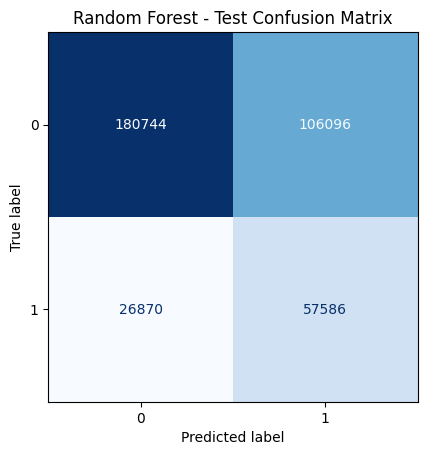

In [31]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues", colorbar=False)

plt.title("Random Forest - Test Confusion Matrix")
plt.show()

In [32]:
feature_names_rf = best_model_rf.named_steps["preprocess"].get_feature_names_out()
importances_rf = best_model_rf.named_steps["model"].feature_importances_

feat_imp_rf = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances_rf
}).sort_values("importance", ascending=False)

display(feat_imp_rf.head(20))

,feature,importance
2,num__int_rate,0.047816
58,num__loan_to_installment,0.043605
57,num__dti_x_int_rate,0.040408
53,num__income_to_loan_ratio,0.027033
6,num__dti,0.024934
54,num__payment_to_income,0.023355
3,num__installment,0.022921
19,num__avg_cur_bal,0.022697
48,num__tot_hi_cred_lim,0.022674
24,num__mo_sin_old_rev_tl_op,0.022251


#### Feature Importance: Random Forest

The Random Forest model identifies **interest rate and loan-to-installment** as the most important predictors, followed by measures of **borrower financial condition and credit risk** such as DTI and payment to income ratio. This aligns with economic intuition: pricing variables and creditworthiness indicators are central to default risk.

Compared to logistic regression coefficients, these importance scores have a different interpretation.  
- In Random Forest, feature importance reflects **how much each variable contributes to improving prediction accuracy across the trees** (e.g., reducing impurity or improving splits).  
- In contrast, logistic regression coefficients measure the **direction and magnitude of effect on default probability (log-odds)**, holding other variables constant.

As a result, Random Forest importance:
- Does **not indicate direction** (positive vs. negative effect)  
- Can capture **nonlinear effects and interactions**  
- Is influenced by how often a feature is used in splits and how much it improves predictions  

Overall, the results suggest that while the key drivers are similar to the linear model, Random Forest captures their importance through **predictive contribution rather than interpretable marginal effects**.

---
## Section 5: Gradient Boosting Model - XGBoost   

In this section, we build a Gradient Boosting model using **XGBoost**, a widely used and high-performing tree-based method.

Unlike Random Forest, which builds many independent trees and averages their predictions, **XGBoost builds trees sequentially**, where each new tree focuses on correcting the errors of the previous ones. This often leads to **better predictive performance**, especially in complex datasets.

XGBoost is extremely popular in industry and data science competitions, and is increasingly used in credit risk modeling, particularly in fintech and advanced analytics teams. However, traditional banks may still rely more on logistic regression due to interpretability and regulatory requirements.

**Pros (vs. linear models)**
- Captures **nonlinear relationships and interactions automatically**
- Often achieves **higher predictive accuracy**
- Flexible and powerful with large datasets

**Cons (vs. linear models)**
- **Less interpretable** than logistic regression
- Requires more **hyperparameter tuning**
- Can be harder to justify in **regulated environments**

Overall, XGBoost provides a useful benchmark for understanding how much predictive performance can be gained from more flexible models.

In [35]:
## Build baseline pipeline
xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

In [36]:
## Fit on training data
start = time.time()

## Fit model
xgb_pipeline.fit(X_train, y_train)

end = time.time()

elapsed = timedelta(seconds=end - start)

print(f"XGBoost = Training time: {elapsed}")

XGBoost = Training time: 0:00:29.365047


In [37]:
param_grid_xgb = [
    {"max_depth": 4, "learning_rate": 0.1,  "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5},
    {"max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5},
    {"max_depth": 6, "learning_rate": 0.05, "subsample": 0.7, "colsample_bytree": 0.7, "min_child_weight": 10},
    {"max_depth": 8, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5},
    {"max_depth": 8, "learning_rate": 0.03, "subsample": 0.6, "colsample_bytree": 0.7, "min_child_weight": 10},
]

results_xgb = []

for params in param_grid_xgb:

    model_xgb = Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            min_child_weight=params["min_child_weight"],
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ))
    ])

    model_xgb.fit(X_train, y_train)

    y_val_proba_xgb = model_xgb.predict_proba(X_val)[:, 1]
    auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)

    results_xgb.append({
        "params": params,
        "val_auc": auc_xgb,
        "model": model_xgb
    })

best_result_xgb = max(results_xgb, key=lambda x: x["val_auc"])
best_model_xgb = best_result_xgb["model"]

print("Best params:", best_result_xgb["params"])
print("Best validation AUC:", best_result_xgb["val_auc"])

Best params: {'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}
Best validation AUC: 0.7220037217672419


In [38]:
## Refit best XGB on train + val combined
best_params_xgb = best_result_xgb["params"]

best_model_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=best_params_xgb["max_depth"],
        learning_rate=best_params_xgb["learning_rate"],
        subsample=best_params_xgb["subsample"],
        colsample_bytree=best_params_xgb["colsample_bytree"],
        min_child_weight=best_params_xgb["min_child_weight"],
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

start = time.time()
best_model_xgb.fit(X_trainval, y_trainval)
print(f"XGB refit on train+val — time: {timedelta(seconds=time.time()-start)}")

XGB refit on train+val — time: 0:00:41.241905


In [39]:
## Show F1-optimal for reference; threshold is already set above
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_val, best_model_xgb.predict_proba(X_val)[:, 1]
)

f1_scores_xgb = 2 * precision_xgb[:-1] * recall_xgb[:-1] / (precision_xgb[:-1] + recall_xgb[:-1] + 1e-8)
best_idx_xgb = np.argmax(f1_scores_xgb)
print(f"F1-optimal threshold for XGB (reference): {thresholds_xgb[best_idx_xgb]:.4f}")
print(f"Using shared threshold: {threshold}")

F1-optimal threshold for XGB (reference): 0.2295
Using shared threshold: 0.22518245576543666


In [40]:
y_test_proba_xgb = best_model_xgb.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_test_proba_xgb >= threshold).astype(int)

print("XGBoost Test Performance:")
print("AUC:      ", roc_auc_score(y_test, y_test_proba_xgb))
print("Precision:", precision_score(y_test, y_test_pred_xgb))
print("Recall:   ", recall_score(y_test, y_test_pred_xgb))
print("F1:       ", f1_score(y_test, y_test_pred_xgb))

XGBoost Test Performance:
AUC:       0.7235545558296088
Precision: 0.3665335259624373
Recall:    0.6638841526948944
F1:        0.47230517169487884


#### Test Performance: XGBoost (Comparison with RF and Logistic Regression)

The XGBoost model achieves **AUC ≈ 0.724**, which is noticably **higher** than both Random Forest and logistic regression (~0.705). This indicates a **meaningful improvement in discriminatory power**, suggesting that more flexible modeling of nonlinearities and interactions adds predictive value.

In terms of classification metrics, XGBoost shows **similar recall (0.66)**. Precision (0.367) is similar to Random Forest and slightly higher than logistic regression, resulting in the **highest F1 score (0.47)** among all models.

Overall, these results suggest that XGBoost provides a **clear improvement over both linear and bagged tree models**, particularly in capturing default cases. This highlights the importance of nonlinear effects and interactions that simpler models are unable to fully exploit.

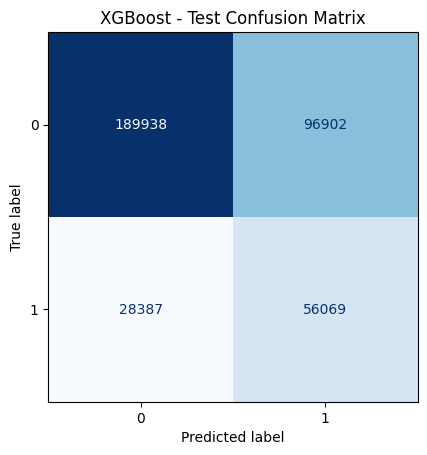

In [42]:
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap="Blues", colorbar=False)

plt.title("XGBoost - Test Confusion Matrix")
plt.show()

In [43]:
feature_names_xgb = best_model_xgb.named_steps["preprocess"].get_feature_names_out()
importances_xgb = best_model_xgb.named_steps["model"].feature_importances_

feat_imp_xgb = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb
}).sort_values("importance", ascending=False)

display(feat_imp_xgb.head(20))

,feature,importance
2,num__int_rate,0.269268
1,num__term,0.089245
60,num__unemployment_rate,0.025512
102,cat__home_ownership_RENT,0.022899
57,num__dti_x_int_rate,0.022441
18,num__acc_open_past_24mths,0.021514
98,cat__home_ownership_MORTGAGE,0.017223
27,num__mort_acc,0.017116
125,cat__fico_band_fair,0.015628
58,num__loan_to_installment,0.015280


#### Feature Importance: XGBoost

The XGBoost model identifies **interest rate, sub-grade categories, and loan term** as the most important features, followed by **credit quality (FICO score)** and measures of **recent credit activity and financial condition**. This is broadly consistent with the Random Forest results and reinforces that **pricing and creditworthiness signals are the primary drivers of default risk**.

Compared to Random Forest, the importance is more **concentrated among a smaller set of top features**, reflecting XGBoost’s sequential learning, where later trees focus on the most informative signals. Sub-grade categories appear prominently, indicating that the model leverages fine-grained credit risk segmentation.

Relative to logistic regression, these importance measures differ in interpretation:
- XGBoost importance reflects **how much each feature improves predictive performance across trees**  
- Logistic regression coefficients measure **direction and magnitude of effect on default probability (log-odds)**  

As a result, XGBoost:
- Does **not provide direction (positive vs. negative impact)**  
- Captures **nonlinearities and interactions**  
- May assign high importance to features that are useful in combination rather than individually  

Overall, while the key drivers are similar across models, XGBoost highlights their importance through **predictive contribution**, offering a different perspective from the more interpretable but restrictive linear model.

---
## Section 6: LightGBM

In this section, we build a **LightGBM** model as an alternative to XGBoost. LightGBM is a gradient boosting framework that uses a **leaf-wise tree growth strategy** (vs. XGBoost's level-wise approach), which often achieves better performance with less training time, especially on large datasets.

Key differences from XGBoost:
- **Faster training:** LightGBM uses histogram-based binning and leaf-wise splitting, making it significantly faster on large datasets like LendingClub.
- **Often better performance:** The leaf-wise strategy can find more precise splits, frequently outperforming XGBoost on tabular data.
- **Key hyperparameters:** `num_leaves` (controls model complexity), `min_child_samples` (minimum samples per leaf), `learning_rate`, and `feature_fraction`/`bagging_fraction` (analogous to XGBoost's `colsample_bytree`/`subsample`).

We tune a small grid over `num_leaves` and `min_child_samples` and compare performance against XGBoost.

In [46]:
param_grid_lgb = [
    {"num_leaves": 31,  "min_child_samples": 20, "learning_rate": 0.05,  "feature_fraction": 0.8, "bagging_fraction": 0.8},
    {"num_leaves": 63,  "min_child_samples": 20, "learning_rate": 0.05,  "feature_fraction": 0.8, "bagging_fraction": 0.8},
    {"num_leaves": 63,  "min_child_samples": 50, "learning_rate": 0.05,  "feature_fraction": 0.7, "bagging_fraction": 0.7},
    {"num_leaves": 127, "min_child_samples": 50, "learning_rate": 0.03,  "feature_fraction": 0.8, "bagging_fraction": 0.8},
    {"num_leaves": 127, "min_child_samples": 100,"learning_rate": 0.03,  "feature_fraction": 0.7, "bagging_fraction": 0.7},
]

results_lgb = []

for params in param_grid_lgb:

    model_lgb = Pipeline([
        ("preprocess", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=300,
            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],
            learning_rate=params["learning_rate"],
            feature_fraction=params["feature_fraction"],
            bagging_fraction=params["bagging_fraction"],
            bagging_freq=5,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ))
    ])

    model_lgb.fit(X_train, y_train)

    y_val_proba_lgb = model_lgb.predict_proba(X_val)[:, 1]
    auc_lgb = roc_auc_score(y_val, y_val_proba_lgb)

    results_lgb.append({
        "params": params,
        "val_auc": auc_lgb,
        "model": model_lgb
    })

best_result_lgb = max(results_lgb, key=lambda x: x["val_auc"])
best_model_lgb = best_result_lgb["model"]

print("Best params:", best_result_lgb["params"])
print("Best validation AUC:", best_result_lgb["val_auc"])

/opt/anaconda3/envs/py310-nlp/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310-nlp/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310-nlp/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310-nlp/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310-nlp/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier wa

Best params: {'num_leaves': 63, 'min_child_samples': 50, 'learning_rate': 0.05, 'feature_fraction': 0.7, 'bagging_fraction': 0.7}
Best validation AUC: 0.7228175463883257


In [47]:
## Refit best LGB on train + val combined
best_params_lgb = best_result_lgb["params"]

best_model_lgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=300,
        num_leaves=best_params_lgb["num_leaves"],
        min_child_samples=best_params_lgb["min_child_samples"],
        learning_rate=best_params_lgb["learning_rate"],
        feature_fraction=best_params_lgb["feature_fraction"],
        bagging_fraction=best_params_lgb["bagging_fraction"],
        bagging_freq=5,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

start = time.time()
best_model_lgb.fit(X_trainval, y_trainval)
print(f"LightGBM refit on train+val — time: {timedelta(seconds=time.time()-start)}")

LightGBM refit on train+val — time: 0:00:39.961148


In [48]:
## Show F1-optimal for reference; threshold is already set above
precision_lgb, recall_lgb, thresholds_lgb = precision_recall_curve(
    y_val, best_model_lgb.predict_proba(X_val)[:, 1]
)

f1_scores_lgb = 2 * precision_lgb[:-1] * recall_lgb[:-1] / (precision_lgb[:-1] + recall_lgb[:-1] + 1e-8)
best_idx_lgb = np.argmax(f1_scores_lgb)
print(f"F1-optimal threshold for LGB (reference): {thresholds_lgb[best_idx_lgb]:.4f}")
print(f"Using shared threshold: {threshold}")

/opt/anaconda3/envs/py310-nlp/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1-optimal threshold for LGB (reference): 0.2304
Using shared threshold: 0.22518245576543666


In [49]:
y_test_proba_lgb = best_model_lgb.predict_proba(X_test)[:, 1]
y_test_pred_lgb = (y_test_proba_lgb >= threshold).astype(int)

print("LightGBM Test Performance:")
print("AUC:      ", roc_auc_score(y_test, y_test_proba_lgb))
print("Precision:", precision_score(y_test, y_test_pred_lgb))
print("Recall:   ", recall_score(y_test, y_test_pred_lgb))
print("F1:       ", f1_score(y_test, y_test_pred_lgb))

/opt/anaconda3/envs/py310-nlp/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Test Performance:
AUC:       0.7241443258708459
Precision: 0.3632997404183845
Recall:    0.6761153736857062
F1:        0.4726360746920938


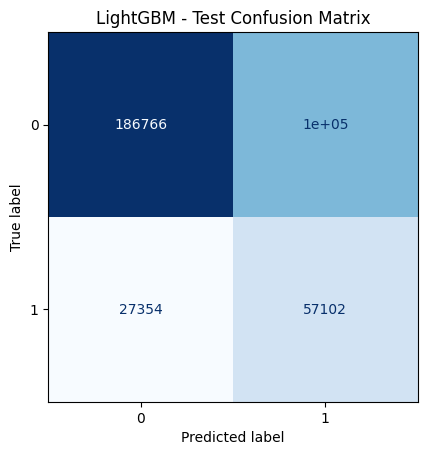

In [50]:
cm_lgb = confusion_matrix(y_test, y_test_pred_lgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lgb)
disp.plot(cmap="Blues", colorbar=False)

plt.title("LightGBM - Test Confusion Matrix")
plt.show()

In [51]:
feature_names_lgb = best_model_lgb.named_steps["preprocess"].get_feature_names_out()
importances_lgb = best_model_lgb.named_steps["model"].feature_importances_

feat_imp_lgb = pd.DataFrame({
    "feature": feature_names_lgb,
    "importance": importances_lgb
}).sort_values("importance", ascending=False)

display(feat_imp_lgb.head(20))

,feature,importance
5,num__annual_inc,703
24,num__mo_sin_old_rev_tl_op,689
2,num__int_rate,630
53,num__income_to_loan_ratio,568
58,num__loan_to_installment,504
50,num__total_bc_limit,498
52,num__credit_age,497
17,num__total_rev_hi_lim,487
60,num__unemployment_rate,481
18,num__acc_open_past_24mths,465
